In [1]:
import karstnet as kn
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import geone as gn
import pandas as pd

## Load cave network data
Here we are loading a medium size cave called th Aulp du Seuil (French Alps).

This is the list of attributes attached to the nodes: ['idsql', 'splays', 'pos', 'flags', 'csdim', 'fulladdress']


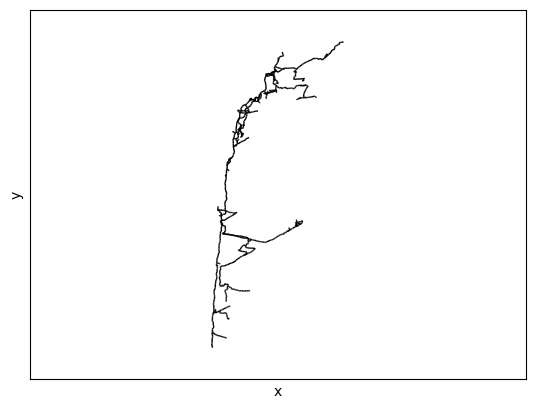

In [2]:
# First the data is loaded from a text file (.yaml)
path_to_yaml = r"..\caves_individual\data\096_AulpSeuil_001\096_AulpSeuil_001.yaml"

G = kn.io_func.networkx_from_yaml(path_to_yaml)
print(f'This is the list of attributes attached to the nodes: {kn.utils.get_node_attribute_names(G)}')
kn.view.plot_graph2d(G, plot_nodes=False, axis_equal=True)

## Correct node numbering
openKARST requires that the node numbering begins at zero and should be consecutive (ie. no gap, such as (0,1,2,4) between nodes is allowed). Because of previous cleaning processes, the networks in KNdatabase can display such gaps. We will not change the node numbering in the database but rather creates new .csv files. Remember than node_id in openKARST will be different from node_id in the database !

In [3]:
#Check is we should change the node numbering
if np.min(G.nodes()) != 0 or np.max(G.nodes()) + 1 != len(G.nodes()) :
    print("Something is odd in node numbering.\n ")
    print("Warning: node_id in openKARSt will be different than node_id in the database")
    dict_index = kn.utils.get_node_label2index_dict(G)   #create a dictionary with the current id (or label) as key and the new label (here the index of the node) as value
    H=nx.relabel_nodes(G,dict_index, copy=True)  #assign the new label to the newly created graph object H
else:
    print("Node numbering should be fine for openKARST")    

Something is odd in node numbering.
 


In [4]:
#small function to go from the new label to the old ones
def search_for_old_label(search_value):
    return [old_label for old_label,new_label in dict_index.items() if new_label == search_value]

search_for_old_label(144)

[2703]

## Get the diameters
openKARST requires that every node of the network has dimensions data. Width and height will be used to compute the diameter of the conduits (by averaging the two endnodes). If the database is incomplete (which is often the case for the diameters), some interpolation will be needed.


In [5]:
#Identify the nodes without any diameter data
missing_diameter=0
for n in H.nodes:
    if H.nodes('csdim')[n] is None:
        missing_diameter+=1 

#check number of missing nodes
if missing_diameter!=0:
   print(missing_diameter, "diameters are missing out of", len(H.nodes), "nodes.")
else:
   print("Everything is fine.")   

196 diameters are missing out of 1862 nodes.


In [6]:
#Identify the nodes with partial information data, for example with known width but no height
#We need to work with G ("old graph") to be able to visualize the Therion data 
csdim=nx.get_node_attributes(G,'csdim')  #dictionary with key=node_id, value= list of cswidth, csheight
list=[]  #count number of 
i=0
for n in csdim:
    if csdim[n][0]==0 or csdim[n][1]==0:
        list.append(n)
        i+=1

#Correction by hand (identification in the karst network, understanding the problem, looking for neighbours, etc...)
#temporary !

csdim[2533]=[3.0, 2.63]
csdim[1375]=[3.0, 4.98]
csdim[2984]=[0.24, 5.00]
csdim[1375]=[3.0, 4.98]
csdim[2115]=[3.3, 3]
csdim[2537]=[0.96, 1.76]
csdim[1253]=[0.5, 1.76]
csdim[2926]=[1.51, 8.94]
csdim[2934]=[1.20, 8.01]
csdim[2306]=[8.0, 3.5]
csdim[1215]=[0.56, 1.00]
csdim[1500]=[1, 1] #strange square of 10 *10 cm (too small for any speleologist to go through)
csdim[2337]=[1,1]  #strange square of 10 *10 cm (too small for any speleologist to go through)
csdim[2141]=[1,1]  #strange square of 10 *10 cm (too small for any speleologist to go through)
csdim[935]=[5.0, 7.00]
csdim[219]=[2.00, 3.40]
csdim[658]=[1.60, 2.00]
csdim[385]=[0.80, 2.00]
csdim[3503]=[3.60, 2.00]
csdim[1682]=[1.90, 2.00]

#Going from values in G (old graph) to values in H (new graph)
new_csdim={}
for label, dim in csdim.items():
    new_csdim[dict_index[label]]= dim 

#Introduce theses values in the graph 
nx.set_node_attributes(H, new_csdim, 'csdim')

#Verify
#H.nodes[dict_index[3503]]

## Distribution of diameters along the graph

Get an idea of the known diameters: what is the distribution of sizes ? Are they all clustered in the same branch of the network ? What is the spatial variation of diameters ?

We will work on the logarithm (log10) of the diameter because the distribution of log(D) is more gaussian-like than the ditribution of D. It also enable to have negative values which will make the random draw easier to do (not restricted to positive values).

The diameters are simply defined as the square root of the width by the height.

In [7]:
#Preparing for visualization
node_sizes_visu = []  #missing diameters stored as zero, list created for visualization purposes
node_diam = []       #only known node diameter, diameter computed as the square root of height by width
log_diam=[]   #get the logarithm of diameter: a more gaussian distribution, negative and positive value (when doing the krigeage, it is better not to be restricted to positive values)
width=[]
height=[]

for n in H.nodes:
    if H.nodes('csdim')[n] is not None:
        node_sizes_visu.append(0)  
        d=np.sqrt(nx.get_node_attributes(H,'csdim')[n][0]*nx.get_node_attributes(H,'csdim')[n][1]) 
        height.append(nx.get_node_attributes(H,'csdim')[n][1])
        width.append(nx.get_node_attributes(H,'csdim')[n][0])
        node_diam.append(d)
        log_diam.append(np.log10(d))
    else:
        node_sizes_visu.append( 20.0 ) 
        node_diam.append(0)


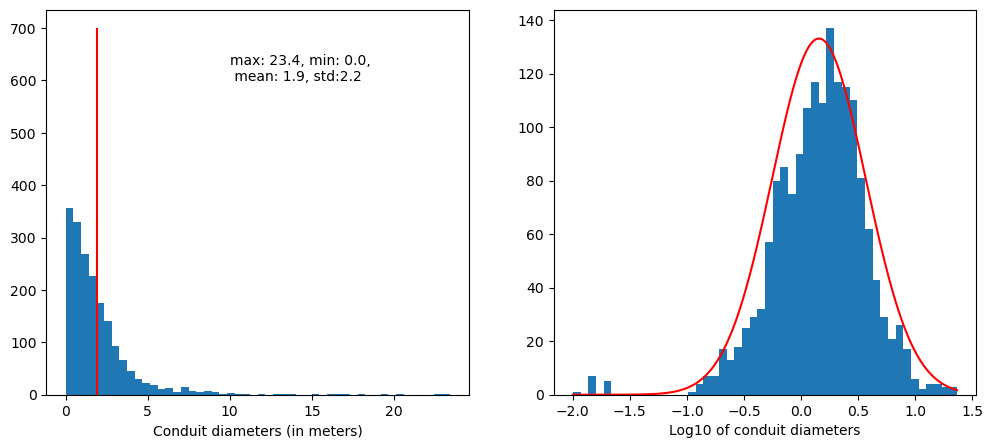

In [8]:
#Compute and display the histogram of the diameter and the histogram of the logarith of the diameter

from scipy.stats import norm
# Compute standard statistics about the data
mean=round(np.mean(node_diam), 2)
min=round(np.min(node_diam), 2)
max=round(np.max(node_diam), 2)
std=round(np.std(node_diam), 2)

nbins=50
fig, axs=plt.subplots(1, 2, figsize=(12,5))

axs[0].hist(node_diam, bins=nbins)
axs[0].vlines(x=mean, ymin=0, ymax=700, colors='red')
axs[0].text(10, 600, s=f"max: {max}, min: {min}, \n mean: {mean}, std:{std}")
axs[0].set_xlabel("Conduit diameters (in meters)")

# add a gaussian distribution line
# x=np.linspace(-2, 2, 50)
# y = norm.pdf(x, loc=np.mean(log_diam), scale=np.std(log_diam))
# axs[1].plot(x, y*130, 'r--', linewidth=1)


def histplot_and_fit(a, n_bins, fit=norm, ax=None):
    if ax is None:
        ax = plt.gca()
    #create an histogram    
    n, b, p = ax.hist(a, bins=n_bins)
    # compute bandwidth
    #bw = len(a)**(-1/5) * np.std(a)
    # initialize PDF support
    #x = np.linspace(a.min()-bw*3, a.max()+bw*3, 200)
    x=np.linspace(b[0], b[-1], n_bins*10)
    # compute PDF parameters
    params = fit.fit(a)
    # compute PDF values
    y = fit.pdf(x, *params)
    # plot the fitted continuous distribution
    ax.plot(x, y*np.max(n), color='r')
    return ax, params


axs[1].set_xlabel("Log10 of conduit diameters")
ax, params =histplot_and_fit(np.array(log_diam), fit=norm, ax=axs[1], n_bins=nbins)

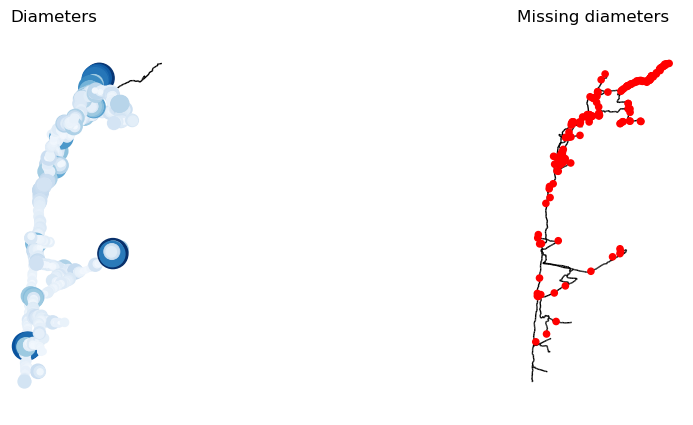

In [9]:
#Visualize diameter data in the graph
fig, axs=plt.subplots(1, 2, figsize=(12,5))

node_diam_visu=[i*20 for i in node_diam]

axs[0].set_title('Diameters', loc='left',ha='left', wrap=True )
nx.draw(H,kn.utils.get_pos2d(H),node_size=node_diam_visu ,with_labels=False, node_color=node_diam_visu, ax=axs[0], cmap=plt.cm.Blues)
axs[0].set_aspect('equal')
plt.plot()

axs[1].set_title('Missing diameters', loc='left',ha='left', wrap=True )
nx.draw(H,kn.utils.get_pos2d(H),node_size=node_sizes_visu ,with_labels=False, node_color='red', ax=axs[1])
axs[1].set_aspect('equal')

## Variograms 

Explore the spatial variations of the diameters: compute th difference of diameters for a couple of nodes separated by a distance h along the edges of the graph (we are not interested by euclidian distances).


This network contains 1 connected components


C:\Users\dufourd\Github\Karstnet-ERC\src\karstnet\tools.py:909: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


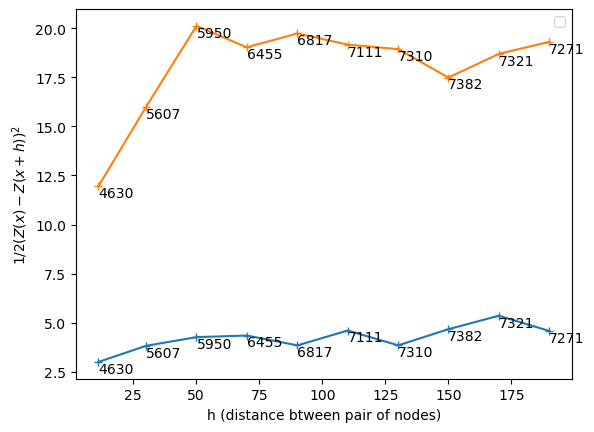

In [10]:
KH=kn.KGraph([], {}, networkx_graph=H)  #transform the graph (from networkx) into a Kgraph (from karstnet)

#Variogram on the whole graph (without thinking about the branches)
ve_h, ve_g, ve_c = KH.variogram_exp('csdim', nsample_start_nodes=1000, hmax=200, 
                                    seed=983)

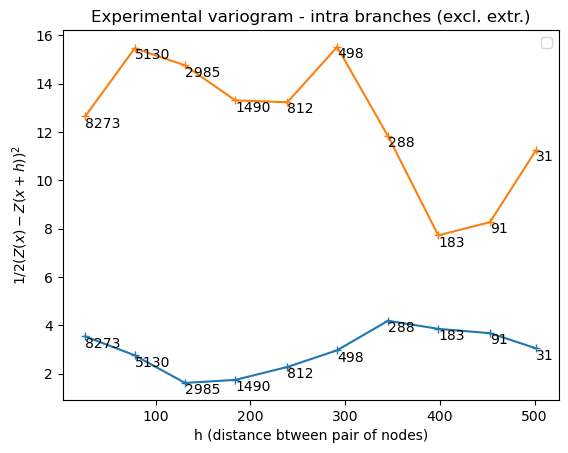

In [11]:
#Experimental variogramm intra branches, of all the branches of the network
ve_h, ve_g, ve_c = KH.variogram_exp_intra_branches('csdim', exclude_branch_extremities=True)
plt.title('Experimental variogram - intra branches (excl. extr.)')
plt.show()

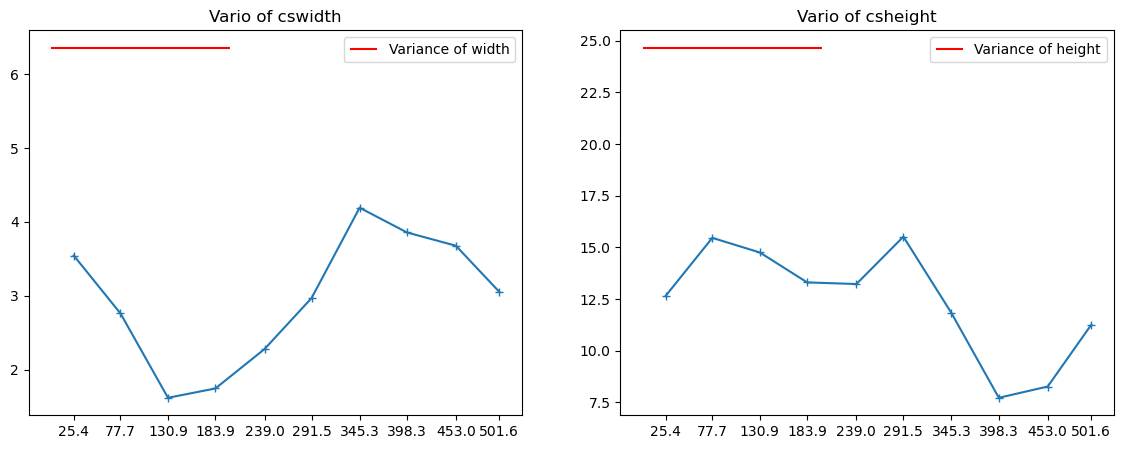

In [12]:
#Variograms on width and height of conduits
std_width=np.std(width)
std_height=np.std(height)
fig, axs =plt.subplots(1, 2, figsize=(14,5))


axs[0].plot(ve_h[:, 0], ve_g[:,0], '+', ls='-')  #label ve_c
axs[0].set_title('Vario of cswidth')
axs[0].hlines(np.square(std_width), 0, 200, 'red', label="Variance of width")
axs[0].set_xticks(ve_h[:,0])
axs[0].legend()


axs[1].plot(ve_h[:, 1], ve_g[:,1], '+', ls='-')  #label ve_c
axs[1].set_title('Vario of csheight')
axs[1].hlines(np.square(std_height), 0, 200, 'red', label="Variance of height")
axs[1].set_xticks(ve_h[:,1])
axs[1].legend()

Based on what information are available, different strategies can be applied.

Strat 1: few data point are missing and they are well distributed in the network => compute a branch mean, intrabranch experimental variogram and simple kriging  
Strat1-bis: same case but with less data: unknown mean diameter on branch, intrabranch variogram and ordinary kriging  
Strat 2: data is missing on only one branch of the network => analyze correlation between the branches, do variogram analysis on the graph of branches  
Strat 3: a lot of data is missing (more than x%), they are well distributed in all the network and the distribution of diameter is regular and not spread => not enough data to do variogramm analysis but possible to draw a diameter for each node in a distribution respecting mean and std of real data  
Strategy 4: more than 90_something % of data is missing and large variance in the diameter distribution, "not able to say anything" => consider using one single value for the all graph (for example 1 meter, or the median of the values...)   

#### The Aulp du Seuil example

In the case of the Aulp du Seuil, the diameters inside a branch show less variability than the data in the whole network. This means that inside a branch the diameters are "homogeneous" (to a certain point). The intrabranch variograms do not show clear spatial trend (closeby nodes do not have more similar diameter than distant nodes, except for the height maybe).
So our strategy will be to fill the missing diameters by picking randomly inside the distribution of each branch.

Strategy for Pierre Chevalier river: a whole branch is missing information =>analyze correlation between the branches, do variogram analysis on the graph of branches 

In [13]:
#Filling the missing diameters branches by branches 
branches=KH.branches
for br in branches:
    br_diam=[]
    br_missing=[]
    br_csdim={}
    for i in br:  #loop on the nodes of a specific branch
        if H.nodes('csdim')[i] is not None:
            w=nx.get_node_attributes(H, 'csdim')[i][0]
            h=nx.get_node_attributes(H, 'csdim')[i][1]
            d=np.sqrt(w*h)
            br_diam.append(np.log10(d))
        else:  
           br_missing.append(i)         
    for node in br_missing:
        l_diam=np.max(br_diam)*np.random.normal(loc=np.mean(br_diam), scale=np.std(br_diam)) 
        if l_diam==0:
            l_diam=0.01
        diam=round(10**l_diam, 2)
        br_csdim[node]=[diam, diam] # pour respecter le rangement des graphes
        #print(diam)
        nx.set_node_attributes(H, br_csdim, 'csdim')

    #fixer une seed pour ne pas reécrire toutes les données à chaque fois ?

#Verify that H is complete

#Identify the nodes without any diameter data
missing_diameter=0
for n in H.nodes:
    if H.nodes('csdim')[n] is None:
        missing_diameter+=1 

#check number of missing nodes
if missing_diameter!=0:
   print(missing_diameter, "diameters are missing out of", len(H.nodes), "nodes.")
else:
   print("Everything is fine.") 

Everything is fine.


In [14]:
#Verify that there is no node with partial informations (only width or height)

csdim2=nx.get_node_attributes(H,'csdim')  #dictionnaire with key=node_id, value= list of cswidth, csheight
list=[]
i=0
for n in csdim2:
    #print(csdim[n][0])
    if csdim2[n][0]==0 or csdim2[n][1]==0:
        #print(n, csdim[n])
        list.append(n)
        i+=1

Text(0.5, 0, 'Log of conduit diameters-new graph')

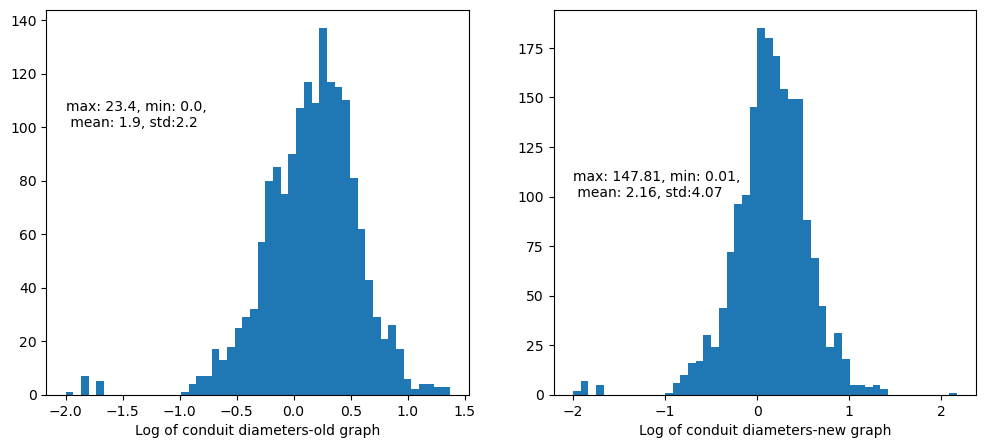

In [15]:
#Visualize the new diameters distribution and compare it with the old one

node_diam_new = []       #only known node diameter, diameter computed as the square root of height by width
log_diam_new=[]   #get the logarithm of diameter: a more gaussian distribution, negative and positive value (when doing the krigeage, it is better not to be restricted to positive values)

for n in H.nodes:
    d=np.sqrt(nx.get_node_attributes(H,'csdim')[n][0]*nx.get_node_attributes(H,'csdim')[n][1]) 
    node_diam_new.append(d)
    log_diam_new.append(round(np.log10(d), 2))

fig, axs=plt.subplots(1, 2, figsize=(12,5))    
axs[0].hist(log_diam, bins=nbins)
axs[0].text(-2, 100, s=f"max: {max}, min: {min}, \n mean: {mean}, std:{std}")
axs[0].set_xlabel("Log of conduit diameters-old graph")


axs[1].hist(log_diam_new, bins=nbins)      
axs[1].text(-2, 100, s=f"max: {round(np.max(node_diam_new),2)}, min: {round(np.min(node_diam_new), 2)}, \n mean: {round(np.mean(node_diam_new), 2)}, std:{round(np.std(node_diam_new),2)}")
axs[1].set_xlabel("Log of conduit diameters-new graph")  


# Export the corrected data

Export the corrected graph in new csv files directly readable by openKARST and its cave_data_loader function. 
Check that the outputh path is different from the path where the original data are loaded, as to not overwrite them.

In [ ]:
cave_name="AulpSeuil"
outputpath="D:\\OneDrive - unine.ch\\Travail\\AulpSeuil"
kn.io_func.networkx_to_kndata_csv(H, outputpath, cavename=cave_name)

#Export the dict_index as a separated csv file, so that you do not lose the correspondance between the old and the new label
#Remember: dict_index.keys=old_label, dict_index.values=new_label

import csv
csv_filename = "correspondance_dict.csv"

with open(outputpath+"\\"+csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows("Old label as first row, New label as second row")
    writer.writerows(dict_index.keys())  # Write header
    writer.writerow(dict_index.values())  # Write values

#pd.DataFrame(dict_index).to_csv(outputpath + cave_name + '_dict.csv', header = ['label_Kndatabase','label_openkarst'], sep=';', encoding = 'utf-8-sig')  

saved edge list to  D:\OneDrive - unine.ch\Travail\AulpSeuil/clean_graph_csv/ AulpSeuil _edges.csv
